c:\ProgramData\anaconda3\envs\scrna\lib\site-packages\anndata\_core\anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Calculating distance matrix and scaling factors...
Computing pairwise distances...
Using 6 threads...
Mean value of sigma: 0.756579
Done. Elapsed time: 8.99 seconds. Total: 8.99 seconds.
Iteration 0 with lasso = 1e-05 in [ 1e-08 , 0.01 ]... Creating model without batches...
Optimizing using OWLQN (because lasso is nonzero)...
0 loss (before this step): 2.7268331050872803 Nonzero (after): 7240 Elapsed time: 868.53 seconds. Total: 877.52 seconds.
1 loss (before this step): 2.1777234077453613 Nonzero (after): 4197 Elapsed time: 680.26 seconds. Total: 1557.78 seconds.
2 loss (before this step): 2.0983259677886963 Nonzero (after): 3477 Elapsed time: 34.65 seconds. Total: 1592.43 seconds.
3 loss (before this step): 2.071939706802368 Nonzero (after): 3208 Elapsed time: 35.88 seconds. Total: 1628.31 seconds.
4 loss (before this step): 2.061422109603882 Nonzero (after): 3003 Elapsed time: 36.09 seconds. Total: 1664.40 seconds.
Final loss: 1.8416746854782104 Nonzero: 3003 Elapsed time: 0.63 seco

c:\ProgramData\anaconda3\envs\scrna\lib\site-packages\scmer\_umap_l1.py:254: UserWarning: Monotonicity is violated. Value lower than current infimum. Binary search may fail. Consider use more max_outer_iter (default: 5) and max_inner_iter (default: 20).
  warnings.warn("Monotonicity is violated. Value lower than current infimum. "


Optimizing using OWLQN (because lasso is nonzero)...
0 loss (before this step): 3.7884178161621094 Nonzero (after): 609 Elapsed time: 40.00 seconds. Total: 3028.36 seconds.
1 loss (before this step): 2.630793571472168 Nonzero (after): 556 Elapsed time: 34.31 seconds. Total: 3062.67 seconds.
2 loss (before this step): 2.6194872856140137 Nonzero (after): 537 Elapsed time: 35.91 seconds. Total: 3098.58 seconds.
3 loss (before this step): 2.6162431240081787 Nonzero (after): 522 Elapsed time: 35.88 seconds. Total: 3134.46 seconds.
4 loss (before this step): 2.613471508026123 Nonzero (after): 511 Elapsed time: 34.31 seconds. Total: 3168.77 seconds.
Final loss: 2.3902735710144043 Nonzero: 511 Elapsed time: 0.63 seconds. Total: 3169.39 seconds.
Done. Number of features: 511 . Elapsed time: 0.00 seconds. Total: 3169.39 seconds.
Iteration 9 with lasso = 0.00012465311192565447 in [ 0.0001229826225655732 , 0.00012634629176544684 ]... Creating model without batches...


c:\ProgramData\anaconda3\envs\scrna\lib\site-packages\scmer\_umap_l1.py:246: UserWarning: Monotonicity is violated. Value larger than current supremum. Binary search may fail. Consider use more max_outer_iter (default: 5) and max_inner_iter (default: 20).
  warnings.warn("Monotonicity is violated. Value larger than current supremum. "


Optimizing using OWLQN (because lasso is nonzero)...
0 loss (before this step): 3.8041138648986816 Nonzero (after): 501 Elapsed time: 39.39 seconds. Total: 3208.78 seconds.
1 loss (before this step): 2.6403512954711914 Nonzero (after): 474 Elapsed time: 33.69 seconds. Total: 3242.47 seconds.
2 loss (before this step): 2.6312856674194336 Nonzero (after): 465 Elapsed time: 34.02 seconds. Total: 3276.49 seconds.
3 loss (before this step): 2.629237174987793 Nonzero (after): 458 Elapsed time: 34.00 seconds. Total: 3310.49 seconds.
4 loss (before this step): 2.6281087398529053 Nonzero (after): 457 Elapsed time: 12.97 seconds. Total: 3323.46 seconds.
Final loss: 2.4167306423187256 Nonzero: 457 Elapsed time: 0.62 seconds. Total: 3324.08 seconds.
Done. Number of features: 457 . Elapsed time: 0.00 seconds. Total: 3324.08 seconds.


c:\ProgramData\anaconda3\envs\scrna\lib\site-packages\scmer\_umap_l1.py:259: UserWarning: max_iter before reached achieving target number of features.
  warnings.warn("max_iter before reached achieving target number of features.")
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19068\3361607351.py:47: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adataRaw.obs["cluster"] = clustering.labels_
c:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
c:\ProgramData\anaconda3\envs\scrna\lib\site-packages\umap\distances.py:1071: NumbaDepreca

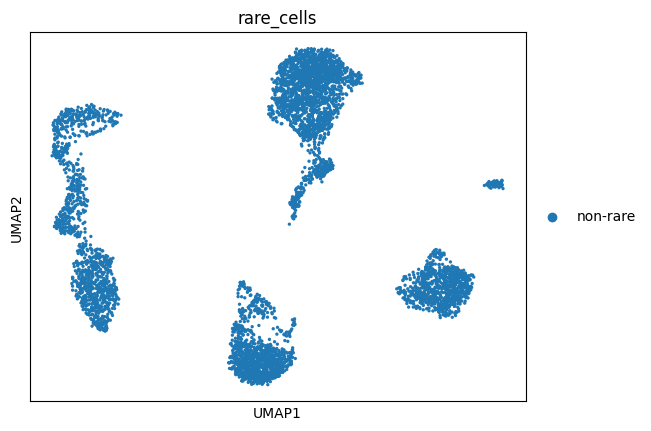

In [1]:
import scanpy as sc
import numpy as np
from scmer import UmapL1  # 使用SCMER库提供的接口
import pandas as pd

# 读取数据
adataRaw = sc.read_h5ad("../output/pbmc_benchmark_data/pbmc_benchmark_s1d1.h5ad")
adataRaw.var_names_make_unique()

# 过滤细胞和基因
sc.pp.filter_cells(adataRaw, min_genes=3)
sc.pp.filter_genes(adataRaw, min_cells=200)

# 确保稀疏矩阵转为密集格式
adataRaw.X = adataRaw.X.toarray()

# 数据归一化
sc.pp.normalize_total(adataRaw, target_sum=1e4)
sc.pp.log1p(adataRaw)

# 检查数据的形状和格式是否正确
assert adataRaw.X.shape[0] > 0 and adataRaw.X.shape[1] > 0, "数据为空，请检查输入文件。"
assert isinstance(adataRaw.X, np.ndarray), "数据格式不正确，确保为密集数组。"

# 使用 SCMER 进行特征选择
# 调整参数以符合 SCMER 的实际需求
model = UmapL1.tune(
    target_n_features=500,  # 目标特征数量
    X=adataRaw.X,           # 输入表达矩阵
    perplexity=30,          # 可选：调整perplexity（默认为30）
    smallest_log10_fold_change=-3,  # 可选：调整log fold change（默认为-3）
    max_iter=10             # 可选：最大迭代次数（默认为10）
)

# 使用调优的模型对数据进行特征降维
selected_adata = model.transform(adataRaw)

# 将选定特征更新到adataRaw对象
adataRaw = selected_adata

# 聚类以识别稀有细胞群
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=0.5, min_samples=10).fit(adataRaw.X)

# 添加聚类结果
adataRaw.obs["cluster"] = clustering.labels_

# 计算稀有细胞簇的占比
cluster_counts = adataRaw.obs["cluster"].value_counts(normalize=True)
rare_clusters = cluster_counts[cluster_counts < 0.05].index  # 小于5%的簇

# 标记稀有细胞
adataRaw.obs["rare_cells"] = "non-rare"
adataRaw.obs.loc[adataRaw.obs["cluster"].isin(rare_clusters), "rare_cells"] = "rare"

# 保存稀有细胞索引
adataRaw.obs["rare_cells"].to_csv("SCMER_rare_cells_indices.csv", index=False)

# 数据标准化和PCA降维
sc.pp.scale(adataRaw)
sc.tl.pca(adataRaw, svd_solver="arpack")

# UMAP可视化稀有细胞群
sc.pp.neighbors(adataRaw, use_rep="X_pca")
sc.tl.umap(adataRaw)
sc.pl.umap(adataRaw, color="rare_cells")
